1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Feature vector: (5, 2048)
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 2.3849
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 2.1772
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 2.0883
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 2.0227
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.9546
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.9021
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1.8517
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 1.8109
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 1.7715
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.7240
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 1.6796
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.6367
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.5984
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 1.5603
Epoch 15/300
1/1 ━━━━━━━━

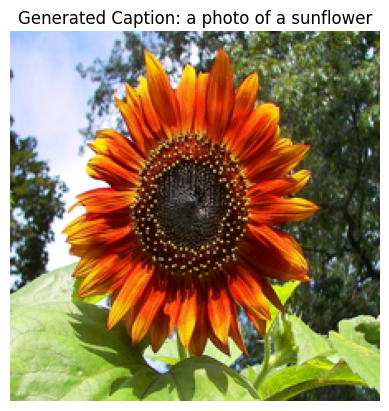

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, RepeatVector, Add
from tensorflow.keras.models import Model
from tensorflow.keras.utils import get_file
from PIL import Image


# 1. CNN encoder
cnn = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)


# 2. ImageNet images
urls = [
    "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
]

captions = [
    "a photo of a sunflower",
    "a photo of a person",
    "a photo of a yellow sunflower",
    "a photo of a woman",
    "a photo of a red sunflower"
]


# 3. Load images
images = []

for url in urls:
    file = get_file(url.split("/")[-1], url)
    img = Image.open(file).resize((224,224)).convert("RGB")
    images.append(np.array(img))

images = np.array(images)


# 4. Extract CNN features
x = preprocess_input(images)
features = cnn.predict(x)

print("Feature vector:", features.shape)


# 5. Tokenize captions
captions = ["<start> " + c + " <end>" for c in captions]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)

seq = tokenizer.texts_to_sequences(captions)
seq = pad_sequences(seq, padding="post")

vocab = len(tokenizer.word_index) + 1

decoder_in = seq[:, :-1]
decoder_out = seq[:, 1:]


# 6. LSTM model
image_input = Input(shape=(2048,))
text_input = Input(shape=(None,))

image_feature = Dense(128, activation="relu")(image_input)
image_feature = RepeatVector(decoder_in.shape[1])(image_feature)

text_feature = Embedding(vocab, 128)(text_input)

x = Add()([image_feature, text_feature])
x = LSTM(128, return_sequences=True)(x)

output = Dense(vocab, activation="softmax")(x)

model = Model(
    [image_input, text_input],
    output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)


# 7. Train
model.fit(
    [features, decoder_in],
    np.expand_dims(decoder_out, -1),
    epochs=300,
    verbose=1
)


# 8. Generate caption
def generate_caption(feature):

    text = "<start>"

    for i in range(10):

        sequence = tokenizer.texts_to_sequences([text])[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=decoder_in.shape[1],
            padding="post"
        )

        prediction = model.predict(
            [feature, sequence],
            verbose=0
        )

        word_id = np.argmax(
            prediction[0, len(text.split())-1]
        )

        if word_id == 0:
            break

        word = tokenizer.index_word[word_id]

        if word == "end":
            break

        text += " " + word

    return text.replace("<start>", "").strip()


# 9. Test image
caption = generate_caption(features[0:1])

print("\nGenerated Caption:", caption)


# 10. Display image and caption
plt.imshow(images[0])
plt.axis("off")
plt.title("Generated Caption: " + caption)
plt.show()